# Importing required Libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [20]:
matches_df = pd.read_csv('../data/WorldCupMatches.csv')
players_df = pd.read_csv('../data/WorldCupPlayers.csv')
cups_df = pd.read_csv('../data/WorldCups.csv')

In [21]:
# Inspecting the DataFrames
matches_df.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


In [22]:
players_df.head()

,RoundID,MatchID,Team Initials,Coach Name,Line-up,Shirt Number,Player Name,Position,Event
0,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Alex THEPOT,GK,NaN
1,201,1096,MEX,LUQUE Juan (MEX),S,0,Oscar BONFIGLIO,GK,NaN
2,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Marcel LANGILLER,NaN,G40'
3,201,1096,MEX,LUQUE Juan (MEX),S,0,Juan CARRENO,NaN,G70'
4,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Ernest LIBERATI,NaN,NaN


In [23]:
cups_df.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1.045.246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768.607


# Data Cleaning and Preprocessing

In [24]:
# Check for null values
print("\nNull values in World Cup Matches Dataset:")
print(matches_df.isnull().sum())

print("\nNull values in World Cup Players Dataset:")
print(players_df.isnull().sum())

print("\nNull values in World Cups Dataset:")
print(cups_df.isnull().sum())


Null values in World Cup Matches Dataset:
Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64

Null values in World Cup Players Dataset:
RoundID              0
MatchID              0
Team Initials        0
Coach Name           0
Line-up              0
Shirt Number         0
Player Name          0
Position         33641
Event            28715
dtype: int64

Null values in World Cups Dataset:
Year              0
Country           0
Winner            0
Runne

In [25]:
matches_df.columns = matches_df.columns.str.strip()
players_df.columns = players_df.columns.str.strip()
cups_df.columns = cups_df.columns.str.strip()

In [26]:
# Convert numerical columns to proper data types where necessary
cups_df['GoalsScored'] = pd.to_numeric(cups_df['GoalsScored'], errors='coerce')
cups_df['MatchesPlayed'] = pd.to_numeric(cups_df['MatchesPlayed'], errors='coerce')
cups_df['Attendance'] = cups_df['Attendance'].str.replace('.', '').astype(float)

In [27]:
# Feature Engineering: Calculate average goals per match for each World Cup
cups_df['AvgGoalsPerMatch'] = cups_df['GoalsScored'] / cups_df['MatchesPlayed']

# Visualization

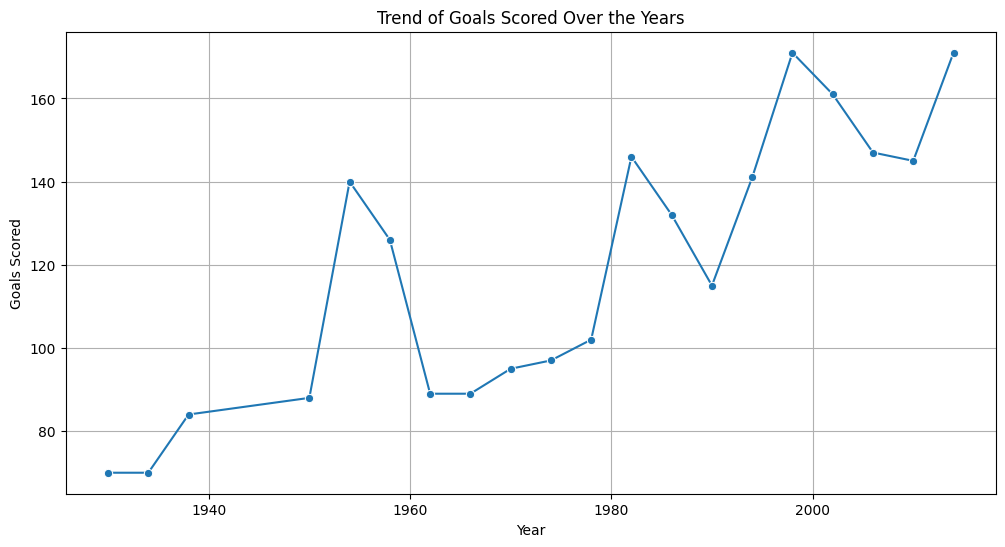

In [28]:
# Analysis 1: Trend of goals scored over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=cups_df, x='Year', y='GoalsScored', marker='o')
plt.title('Trend of Goals Scored Over the Years')
plt.xlabel('Year')
plt.ylabel('Goals Scored')
plt.grid()
plt.show()

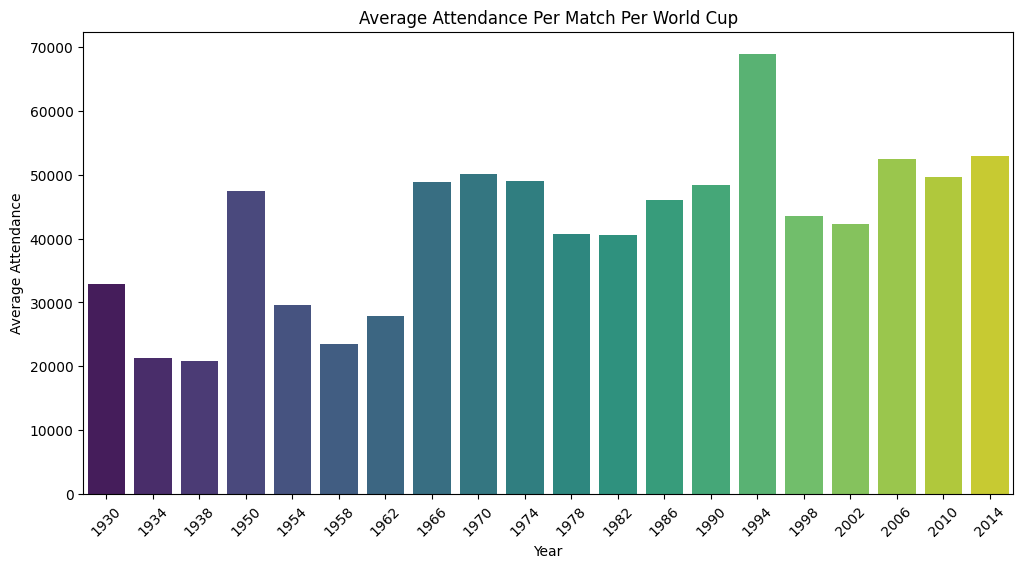

In [29]:
# Analysis 2: Average attendance per match per World Cup
cups_df['AvgAttendance'] = cups_df['Attendance'] / cups_df['MatchesPlayed']

plt.figure(figsize=(12, 6))
sns.barplot(data=cups_df, x='Year', y='AvgAttendance', palette='viridis')
plt.title('Average Attendance Per Match Per World Cup')
plt.xlabel('Year')
plt.ylabel('Average Attendance')
plt.xticks(rotation=45)
plt.show()

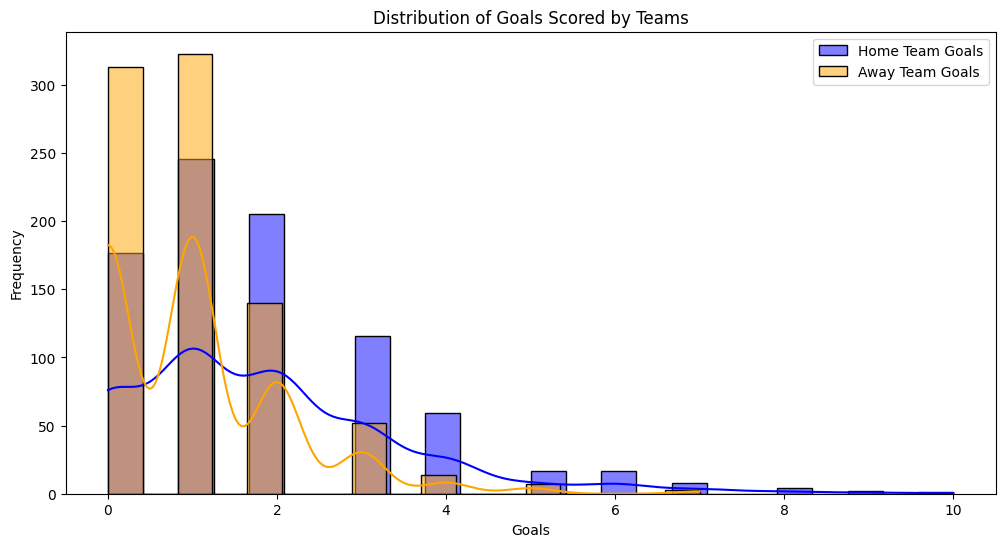

In [30]:
# Analysis 3: Distribution of goals scored by home and away teams in matches
plt.figure(figsize=(12, 6))
sns.histplot(matches_df['Home Team Goals'], color='blue', label='Home Team Goals', kde=True)
sns.histplot(matches_df['Away Team Goals'], color='orange', label='Away Team Goals', kde=True)
plt.title('Distribution of Goals Scored by Teams')
plt.xlabel('Goals')
plt.ylabel('Frequency')
plt.legend()
plt.show()

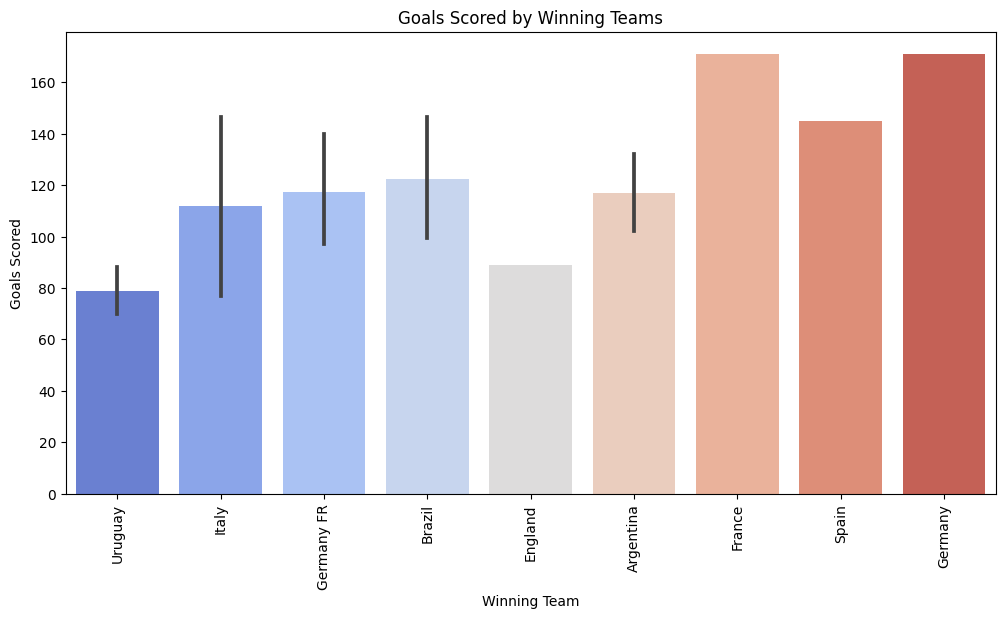

In [31]:
# Analysis 4: Relationship between goals scored and wins
cups_df['WinnerGoals'] = cups_df['GoalsScored']
plt.figure(figsize=(12, 6))
sns.barplot(data=cups_df, x='Winner', y='WinnerGoals', palette='coolwarm')
plt.title('Goals Scored by Winning Teams')
plt.xlabel('Winning Team')
plt.ylabel('Goals Scored')
plt.xticks(rotation=90)
plt.show()

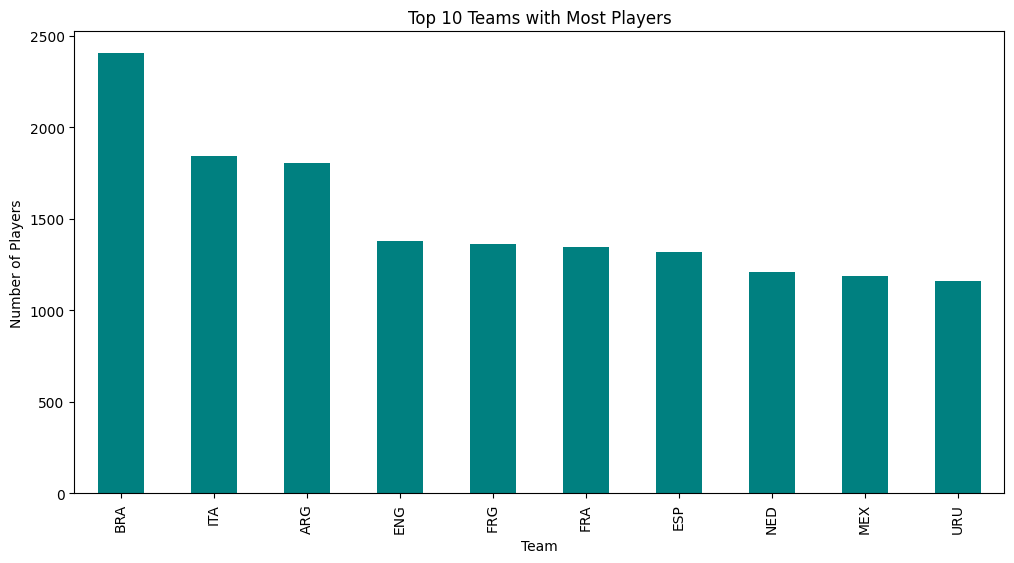

In [32]:
# Analysis 5: Key metrics for top-performing players
player_counts = players_df['Team Initials'].value_counts().head(10)
plt.figure(figsize=(12, 6))
player_counts.plot(kind='bar', color='teal')
plt.title('Top 10 Teams with Most Players')
plt.xlabel('Team')
plt.ylabel('Number of Players')
plt.show()

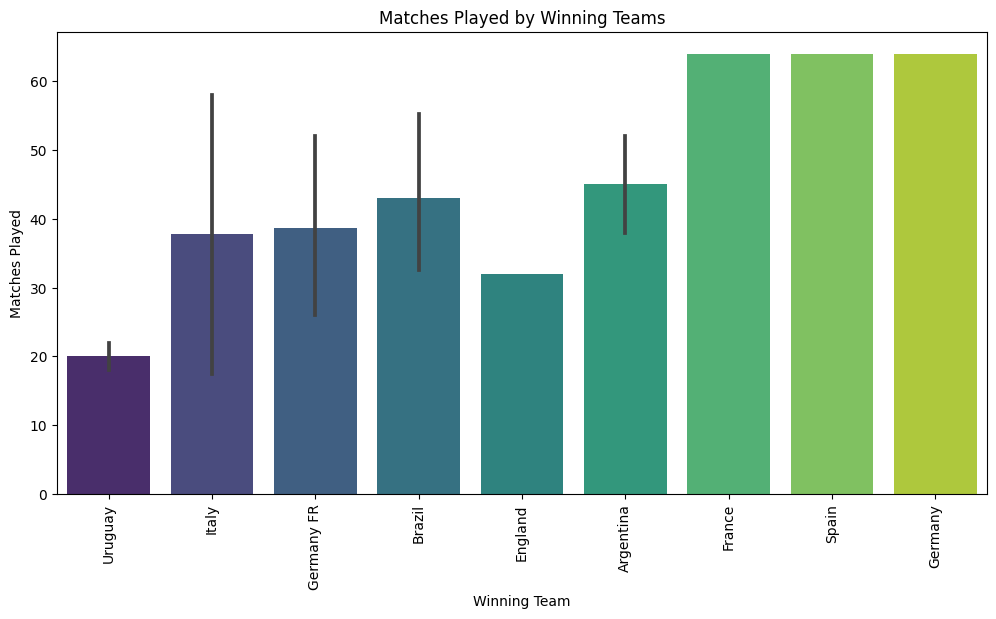

In [33]:
# Analysis 6: Winning teams and their metrics
plt.figure(figsize=(12, 6))
sns.barplot(data=cups_df, x='Winner', y='MatchesPlayed', palette='viridis')
plt.title('Matches Played by Winning Teams')
plt.xlabel('Winning Team')
plt.ylabel('Matches Played')
plt.xticks(rotation=90)
plt.show()

# Key Findings and Summary

1. Goals scored per World Cup have generally increased over time, with notable peaks in certain years.
2. Average attendance per match provides insights into the popularity and reach of the tournament.
3. Home teams tend to score slightly more goals compared to away teams.
4. Teams with the most goals scored often end up winning the tournament.
5. Brazil stands out with consistent high performance and number of players contributing.

In [34]:
avg_home_goals = matches_df['Home Team Goals'].mean()
avg_away_goals = matches_df['Away Team Goals'].mean()
print(f"Average Home Team Goals: {avg_home_goals}")
print(f"Average Away Team Goals: {avg_away_goals}")

Average Home Team Goals: 1.8110328638497653
Average Away Team Goals: 1.022300469483568
